In [1]:
# goal for this notebook: explain cross-zone differences in expected net earnings
# per hour from the simulation using zone-level features like avg trip revenue,
# avg trip duration, expected wait time, and manhattan / airport indicators

import duckdb

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [3]:
# project paths
project_root = Path("..")
cleaned_dir = project_root / "data" / "cleaned"
raw_dir = project_root / "data" / "raw"

# connect to DuckDB
con = duckdb.connect()

In [4]:
# load zone lookup table

zones = con.execute(f"""
SELECT *
FROM read_csv_auto('{raw_dir.as_posix()}/taxi_zone_lookup.csv')
""").fetchdf()

zones.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [5]:
# create explanatory variables for the regression

zone_features = con.execute(f"""
SELECT
    t.PULocationID,

    AVG(total_amount) AS avg_trip_revenue,

    AVG(
        EXTRACT(EPOCH FROM (tpep_dropoff_datetime - tpep_pickup_datetime)) / 60.0
    ) AS avg_trip_minutes,

    AVG(trip_distance) AS avg_trip_distance,

    COUNT(*) AS total_pickups

FROM read_parquet('{cleaned_dir.as_posix()}/yellow_tripdata_2024-*.parquet') t

LEFT JOIN read_csv_auto('{raw_dir.as_posix()}/taxi_zone_lookup.csv') z
    ON t.PULocationID = z.LocationID

WHERE
    total_amount > 0
    AND z.Borough != 'EWR'
    AND EXTRACT(hour FROM tpep_pickup_datetime) BETWEEN 8 AND 19

GROUP BY
    t.PULocationID
""").fetchdf()

zone_features.head()

,PULocationID,avg_trip_revenue,avg_trip_minutes,avg_trip_distance,total_pickups
0,230,30.524348,18.931134,3.594760,828014
1,158,26.428884,17.379998,2.762243,196896
2,137,22.980118,14.914238,4.860139,291894
3,228,36.830896,40.170959,7.175915,3048
4,88,34.250150,22.613543,7.690951,81009


In [6]:
# rebuild wait-time features

zone_hour_flows = con.execute(f"""
SELECT
    zone_id,
    hour,
    SUM(pickups) AS pickups,
    SUM(dropoffs) AS dropoffs
FROM (

    SELECT
        PULocationID AS zone_id,
        EXTRACT(hour FROM tpep_pickup_datetime) AS hour,
        COUNT(*) AS pickups,
        0 AS dropoffs
    FROM read_parquet('{cleaned_dir.as_posix()}/yellow_tripdata_2024-*.parquet')
    WHERE
        total_amount > 0
        AND EXTRACT(hour FROM tpep_pickup_datetime) BETWEEN 8 AND 19
    GROUP BY
        PULocationID,
        hour

    UNION ALL

    SELECT
        DOLocationID AS zone_id,
        EXTRACT(hour FROM tpep_dropoff_datetime) AS hour,
        0 AS pickups,
        COUNT(*) AS dropoffs
    FROM read_parquet('{cleaned_dir.as_posix()}/yellow_tripdata_2024-*.parquet')
    WHERE
        total_amount > 0
        AND EXTRACT(hour FROM tpep_dropoff_datetime) BETWEEN 8 AND 19
    GROUP BY
        DOLocationID,
        hour

)
GROUP BY
    zone_id,
    hour
""").fetchdf()

zone_hour_flows.head()

,zone_id,hour,pickups,dropoffs
0,232,18,3234.0,14289.0
1,239,18,78403.0,94066.0
2,113,18,40440.0,43975.0
3,143,18,32233.0,45887.0
4,234,18,86431.0,76389.0


In [7]:
# convert flows into expected wait time

zone_hour_flows["pickups"] = zone_hour_flows["pickups"].clip(lower=1)

zone_hour_flows["dropoff_pickup_ratio"] = (
    zone_hour_flows["dropoffs"] / zone_hour_flows["pickups"]
)

wait_scale = 5.0

zone_hour_flows["expected_wait_minutes"] = (
    wait_scale * zone_hour_flows["dropoff_pickup_ratio"]
)

zone_hour_flows["expected_wait_minutes"] = (
    zone_hour_flows["expected_wait_minutes"].clip(lower=1, upper=30)
)

zone_hour_flows.head()

,zone_id,hour,pickups,dropoffs,dropoff_pickup_ratio,expected_wait_minutes
0,232,18,3234.0,14289.0,4.418367,22.091837
1,239,18,78403.0,94066.0,1.199776,5.998878
2,113,18,40440.0,43975.0,1.087413,5.437067
3,143,18,32233.0,45887.0,1.423603,7.118016
4,234,18,86431.0,76389.0,0.883815,4.419074


In [8]:
# collapse wait time to zone level

zone_wait = (
    zone_hour_flows
    .groupby("zone_id", as_index=False)["expected_wait_minutes"]
    .mean()
    .rename(columns={"zone_id": "PULocationID"})
)

zone_wait.head()

,PULocationID,expected_wait_minutes
0,1,30.000000
1,2,8.670635
2,3,14.249724
3,4,16.862840
4,5,20.416667


In [9]:
# load simulation results

zone_results = pd.read_csv(project_root / "data" / "zone_results.csv")
zone_results.head()

,PULocationID,Zone,Borough,expected_net_earnings_per_hour,std_net_earnings_per_hour
0,93,Flushing Meadows-Corona Park,Queens,69.040984,6.713944
1,70,East Elmhurst,Queens,66.721398,7.221374
2,195,Red Hook,Brooklyn,66.369145,7.531864
3,138,LaGuardia Airport,Queens,66.178865,6.537119
4,263,Yorkville West,Manhattan,66.126178,5.409338


In [10]:
# merge everything together

analysis_df = (
    zone_results
    .merge(zone_features, on="PULocationID", how="left")
    .merge(zone_wait, on="PULocationID", how="left")
    .merge(
        zones[["LocationID", "Borough", "Zone"]],
        left_on="PULocationID",
        right_on="LocationID",
        how="left"
    )
)

analysis_df.head()

,PULocationID,Zone_x,Borough_x,expected_net_earnings_per_hour,std_net_earnings_per_hour,avg_trip_revenue,avg_trip_minutes,avg_trip_distance,total_pickups,expected_wait_minutes,LocationID,Borough_y,Zone_y
0,93,Flushing Meadows-Corona Park,Queens,69.040984,6.713944,71.036044,29.696335,8.942773,6117,11.849830,93,Queens,Flushing Meadows-Corona Park
1,70,East Elmhurst,Queens,66.721398,7.221374,68.483424,34.301031,9.663198,107643,1.000000,70,Queens,East Elmhurst
2,195,Red Hook,Brooklyn,66.369145,7.531864,59.228896,33.920049,21.816679,5814,18.030381,195,Brooklyn,Red Hook
3,138,LaGuardia Airport,Queens,66.178865,6.537119,70.661458,35.196780,9.823539,899606,2.248991,138,Queens,LaGuardia Airport
4,263,Yorkville West,Manhattan,66.126178,5.409338,21.257421,12.238360,2.985914,517442,4.879950,263,Manhattan,Yorkville West


In [12]:
analysis_df.columns

Index(['PULocationID', 'Zone_x', 'Borough_x', 'expected_net_earnings_per_hour',
       'std_net_earnings_per_hour', 'avg_trip_revenue', 'avg_trip_minutes',
       'avg_trip_distance', 'total_pickups', 'expected_wait_minutes',
       'LocationID', 'Borough_y', 'Zone_y'],
      dtype='str')

In [13]:
analysis_df[["Borough_x","Borough_y"]].head()

,Borough_x,Borough_y
0,Queens,Queens
1,Queens,Queens
2,Brooklyn,Brooklyn
3,Queens,Queens
4,Manhattan,Manhattan


In [14]:
# create dummy variables

analysis_df["manhattan"] = (
    analysis_df["Borough_x"] == "Manhattan"
).astype(int)

airport_zone_ids = [132, 138]

analysis_df["airport_zone"] = (
    analysis_df["PULocationID"].isin(airport_zone_ids)
).astype(int)

analysis_df[["PULocationID", "Zone_x" if "Zone_x" in analysis_df.columns else "Zone", "manhattan", "airport_zone"]].head()

,PULocationID,Zone_x,manhattan,airport_zone
0,93,Flushing Meadows-Corona Park,0,0
1,70,East Elmhurst,0,0
2,195,Red Hook,0,0
3,138,LaGuardia Airport,0,1
4,263,Yorkville West,1,0


In [15]:
# clean up duplicate zone/borough columns if needed

if "Zone_x" in analysis_df.columns:
    analysis_df = analysis_df.rename(columns={"Zone_x": "Zone"})
if "Borough_x" in analysis_df.columns:
    analysis_df = analysis_df.rename(columns={"Borough_x": "Borough"})

cols_to_drop = [c for c in ["Zone_y", "Borough_y", "LocationID"] if c in analysis_df.columns]
analysis_df = analysis_df.drop(columns=cols_to_drop)

analysis_df.head()

,PULocationID,Zone,Borough,expected_net_earnings_per_hour,std_net_earnings_per_hour,avg_trip_revenue,avg_trip_minutes,avg_trip_distance,total_pickups,expected_wait_minutes,manhattan,airport_zone
0,93,Flushing Meadows-Corona Park,Queens,69.040984,6.713944,71.036044,29.696335,8.942773,6117,11.849830,0,0
1,70,East Elmhurst,Queens,66.721398,7.221374,68.483424,34.301031,9.663198,107643,1.000000,0,0
2,195,Red Hook,Brooklyn,66.369145,7.531864,59.228896,33.920049,21.816679,5814,18.030381,0,0
3,138,LaGuardia Airport,Queens,66.178865,6.537119,70.661458,35.196780,9.823539,899606,2.248991,0,1
4,263,Yorkville West,Manhattan,66.126178,5.409338,21.257421,12.238360,2.985914,517442,4.879950,1,0


In [16]:
# quick descriptive check

analysis_df[[
    "expected_net_earnings_per_hour",
    "avg_trip_revenue",
    "avg_trip_minutes",
    "avg_trip_distance",
    "expected_wait_minutes",
    "total_pickups"
]].describe()

,expected_net_earnings_per_hour,avg_trip_revenue,avg_trip_minutes,avg_trip_distance,expected_wait_minutes,total_pickups
count,179.000000,179.000000,179.000000,179.000000,179.000000,1.790000e+02
mean,60.507565,34.364602,29.834427,16.973015,11.582800,1.475520e+05
std,4.199274,11.819339,12.137736,19.081675,5.797413,2.911450e+05
min,43.714564,20.996913,12.238360,2.069781,1.000000,1.263000e+03
25%,57.273861,26.362268,18.252327,4.957032,6.910635,2.520500e+03
50%,60.711968,31.860466,30.129215,9.261407,11.137709,6.217000e+03
75%,64.295581,37.212394,39.533192,20.776304,14.396279,1.352445e+05
max,69.040984,85.028421,66.565080,126.906986,30.000000,1.454265e+06


In [17]:
# run the main regression

X = analysis_df[[
    "avg_trip_revenue",
    "avg_trip_minutes",
    "expected_wait_minutes",
    "avg_trip_distance",
    "manhattan"
]]

X = sm.add_constant(X)

y = analysis_df["expected_net_earnings_per_hour"]

model = sm.OLS(y, X).fit()

print(model.summary())

                                  OLS Regression Results                                  
Dep. Variable:     expected_net_earnings_per_hour   R-squared:                       0.690
Model:                                        OLS   Adj. R-squared:                  0.681
Method:                             Least Squares   F-statistic:                     77.14
Date:                            Wed, 11 Mar 2026   Prob (F-statistic):           3.25e-42
Time:                                    13:49:44   Log-Likelihood:                -405.41
No. Observations:                             179   AIC:                             822.8
Df Residuals:                                 173   BIC:                             841.9
Df Model:                                       5                                         
Covariance Type:                        nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]


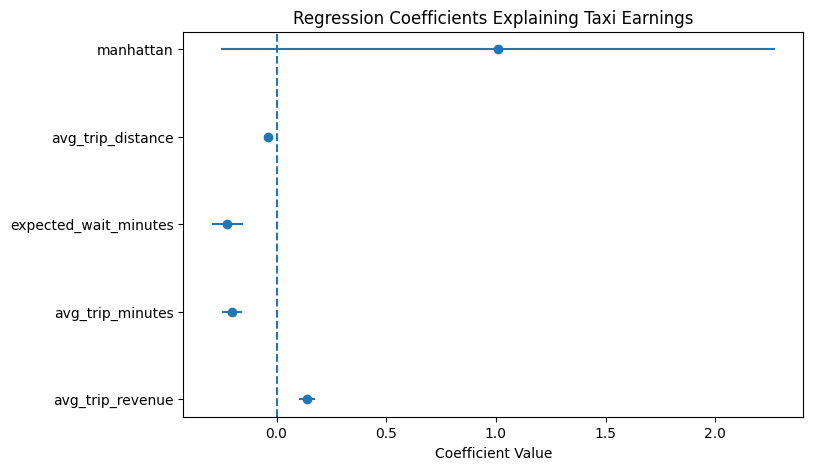

In [18]:
# coefficient plot

coef = model.params
conf = model.conf_int()

coef_df = pd.DataFrame({
    "coef": coef,
    "lower": conf[0],
    "upper": conf[1]
})

coef_df = coef_df.drop("const")

plt.figure(figsize=(8,5))

plt.errorbar(
    coef_df["coef"],
    coef_df.index,
    xerr=[
        coef_df["coef"] - coef_df["lower"],
        coef_df["upper"] - coef_df["coef"]
    ],
    fmt="o"
)

plt.axvline(0, linestyle="--")

plt.xlabel("Coefficient Value")
plt.title("Regression Coefficients Explaining Taxi Earnings")

plt.show()

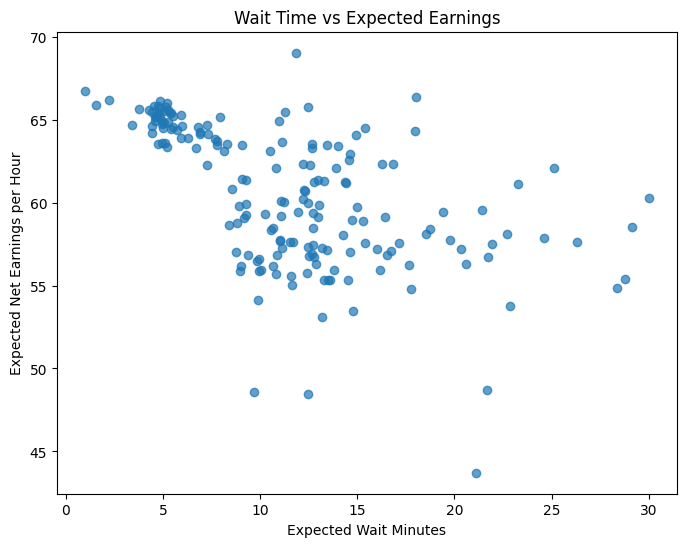

In [19]:
# simple scatterplot

plt.figure(figsize=(8,6))
plt.scatter(
    analysis_df["expected_wait_minutes"],
    analysis_df["expected_net_earnings_per_hour"],
    alpha=0.7
)
plt.xlabel("Expected Wait Minutes")
plt.ylabel("Expected Net Earnings per Hour")
plt.title("Wait Time vs Expected Earnings")
plt.show()

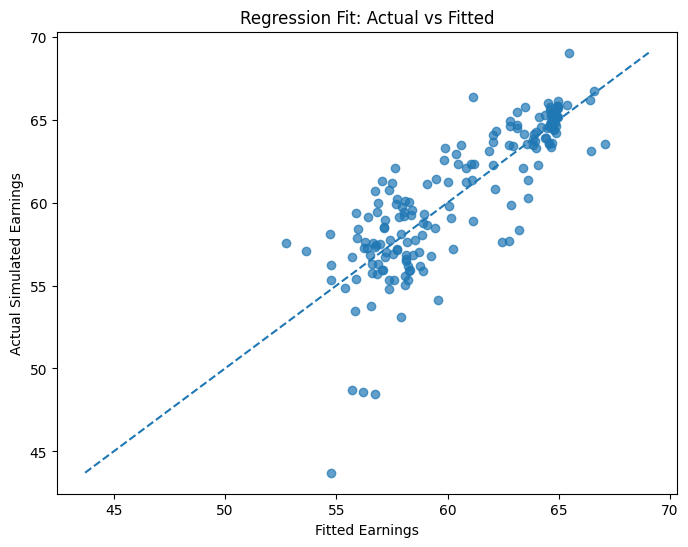

In [21]:
# fitted vs actual - how well does regression explain the simulation

analysis_df["fitted"] = model.fittedvalues

plt.figure(figsize=(8,6))
plt.scatter(
    analysis_df["fitted"],
    analysis_df["expected_net_earnings_per_hour"],
    alpha=0.7
)

min_val = min(analysis_df["fitted"].min(), analysis_df["expected_net_earnings_per_hour"].min())
max_val = max(analysis_df["fitted"].max(), analysis_df["expected_net_earnings_per_hour"].max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Fitted Earnings")
plt.ylabel("Actual Simulated Earnings")
plt.title("Regression Fit: Actual vs Fitted")
plt.show()

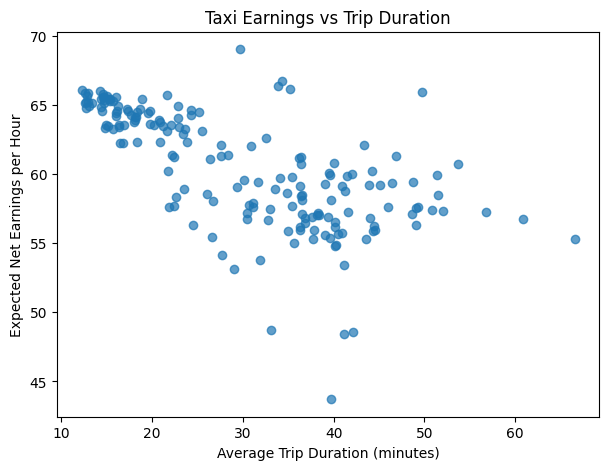

In [24]:
# trip duration vs earnings

plt.figure(figsize=(7,5))

plt.scatter(
    analysis_df["avg_trip_minutes"],
    analysis_df["expected_net_earnings_per_hour"],
    alpha=0.7
)

plt.xlabel("Average Trip Duration (minutes)")
plt.ylabel("Expected Net Earnings per Hour")

plt.title("Taxi Earnings vs Trip Duration")

plt.show()

In [22]:
# inspect zone 93 specifically

analysis_df.loc[analysis_df["PULocationID"] == 93]

,PULocationID,Zone,Borough,expected_net_earnings_per_hour,std_net_earnings_per_hour,avg_trip_revenue,avg_trip_minutes,avg_trip_distance,total_pickups,expected_wait_minutes,manhattan,airport_zone,fitted
0,93,Flushing Meadows-Corona Park,Queens,69.040984,6.713944,71.036044,29.696335,8.942773,6117,11.84983,0,0,65.473322


In [23]:
# compare zone 93 to top Manhattan zones

analysis_df.sort_values(
    "expected_net_earnings_per_hour",
    ascending=False
)[[
    "PULocationID",
    "Zone",
    "Borough",
    "expected_net_earnings_per_hour",
    "avg_trip_revenue",
    "avg_trip_minutes",
    "expected_wait_minutes",
    "avg_trip_distance",
    "manhattan"
]].head(15)

,PULocationID,Zone,Borough,expected_net_earnings_per_hour,avg_trip_revenue,avg_trip_minutes,expected_wait_minutes,avg_trip_distance,manhattan
0,93,Flushing Meadows-Corona Park,Queens,69.040984,71.036044,29.696335,11.849830,8.942773,0
1,70,East Elmhurst,Queens,66.721398,68.483424,34.301031,1.000000,9.663198,0
2,195,Red Hook,Brooklyn,66.369145,59.228896,33.920049,18.030381,21.816679,0
3,138,LaGuardia Airport,Queens,66.178865,70.661458,35.196780,2.248991,9.823539,0
4,263,Yorkville West,Manhattan,66.126178,21.257421,12.238360,4.879950,2.985914,1
5,24,Bloomingdale,Manhattan,66.038159,22.511556,14.303003,5.203392,6.256197,1
6,132,JFK Airport,Queens,65.910361,85.028421,49.772685,1.536849,16.163378,0
7,236,Upper East Side North,Manhattan,65.853919,21.152690,12.621888,4.731159,2.725322,1
8,239,Upper West Side South,Manhattan,65.844149,21.954290,12.955605,4.557799,3.091698,1
9,249,West Village,Manhattan,65.781707,22.609416,14.617429,5.159986,2.841517,1


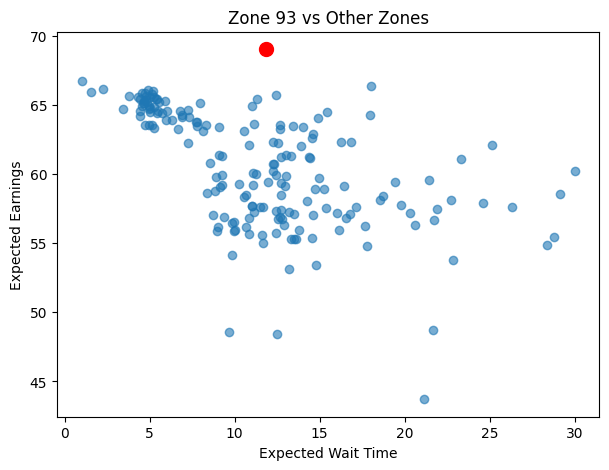

In [25]:
# highlight zone 93

plt.figure(figsize=(7,5))

plt.scatter(
    analysis_df["expected_wait_minutes"],
    analysis_df["expected_net_earnings_per_hour"],
    alpha=0.6
)

zone93 = analysis_df[analysis_df["PULocationID"] == 93]

plt.scatter(
    zone93["expected_wait_minutes"],
    zone93["expected_net_earnings_per_hour"],
    color="red",
    s=100
)

plt.xlabel("Expected Wait Time")
plt.ylabel("Expected Earnings")

plt.title("Zone 93 vs Other Zones")

plt.show()